## 1. Data Acquisition and Descriptive Statistics

The `iris_extended.csv` dataset comprises 1,200 observations (n=400 per species) across three taxa: *I. setosa*, *I. versicolor*, and *I. virginica*. The feature space includes 20 parameters consisting of raw morphological measurements and engineered metrics. Preliminary inspection confirms a balanced dataset with zero missing values, obviating the need for imputation and ensuring that classification accuracy remains a reliable metric for performance evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import ttest_ind
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Load dataset as pandas dataframe
df = pd.read_csv('iris_extended.csv')

In [2]:
# Inspect data
print(f'\nShape: {df.shape}') # Print the number of rows and columns
print(f'\nData types: \n{df.dtypes}') # Print data types of each column
print(f'\nFirst five rows: \n{df.head()}') # Display the first 5 rows of the DataFrame
print(f'\nSummary statistics: \n{df.describe()}') # Display descriptive statistics for numerical columns
print(f'\nTotal missing values: \n{df.isnull().sum()}') # Count and display missing values per column


Shape: (1200, 21)

Data types: 
species                             object
elevation                          float64
soil_type                           object
sepal_length                       float64
sepal_width                        float64
petal_length                       float64
petal_width                        float64
sepal_area                         float64
petal_area                         float64
sepal_aspect_ratio                 float64
petal_aspect_ratio                 float64
sepal_to_petal_length_ratio        float64
sepal_to_petal_width_ratio         float64
sepal_petal_length_diff            float64
sepal_petal_width_diff             float64
petal_curvature_mm                 float64
petal_texture_trichomes_per_mm2    float64
leaf_area_cm2                      float64
sepal_area_sqrt                    float64
petal_area_sqrt                    float64
area_ratios                        float64
dtype: object

First five rows: 
  species  elevation soil_type 

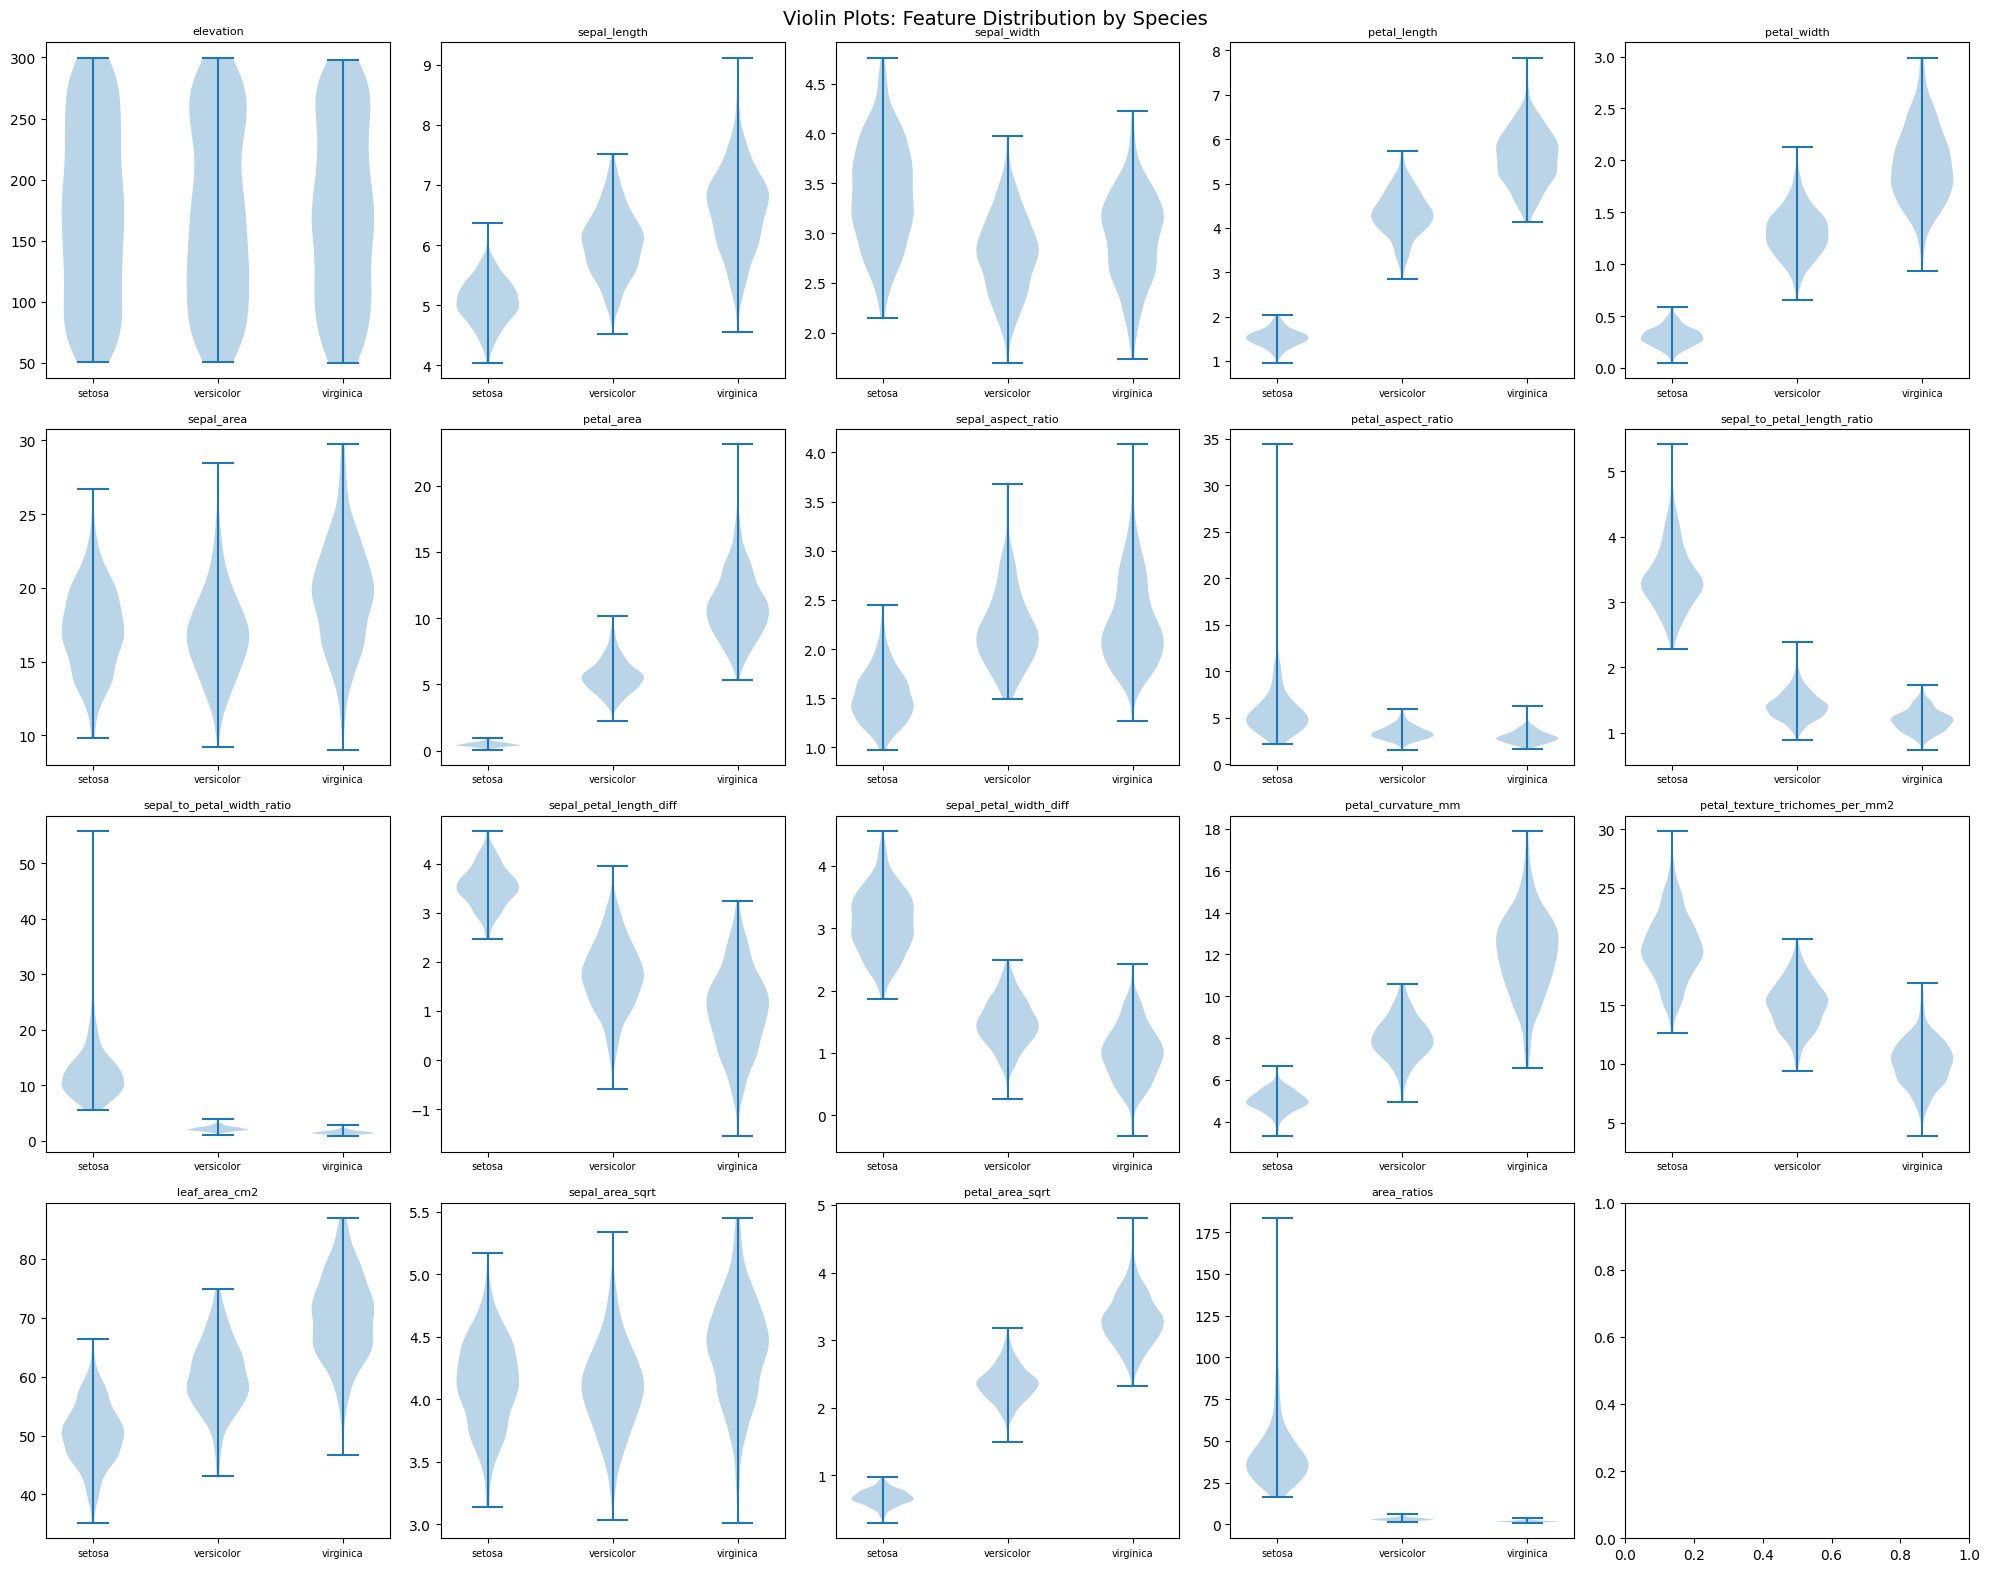

In [3]:
# Check if data is normally distributed

# Extracts columns with numeric data types from the dataframe and stores them as a list
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

# Loop through each numeric column/feature
for i, col in enumerate(numeric_cols):
    # Loop through species ['setosa', 'versicolor', 'virginica']
    # Extracts numeric values for that species for every column/feature
    data_by_species = [df[df['species'] == sp][col].values for sp in df.species.unique().tolist()]
    axes[i].violinplot(data_by_species, positions=[1,2,3])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xticks([1,2,3])
    axes[i].set_xticklabels(['setosa', 'versicolor', 'virginica'], fontsize=7)

plt.suptitle('Violin Plots: Feature Distribution by Species', fontsize=14)
plt.tight_layout()
plt.show()

## 2. Morphological Variance Analysis (Violin Plots)

Violin plots visualise the probability density of each feature across the three species. *I. setosa* exhibits a distinct, non-overlapping distribution in petal-related features, suggesting high linear separability. In contrast, *I. versicolor* and *I. virginica* display significant morphological overlap, particularly in sepal dimensions, indicating that these species pairs will likely require high-dimensional feature combinations for accurate classification.

In [4]:
# Encode species to 0, 1, 2
le = LabelEncoder()
df['species_encoded'] = le.fit_transform(df['species'])
print(le.classes_)

# One-hot encoding for soil_type if it exists to avoid KeyError on re-run
if 'soil_type' in df.columns:
    df = pd.get_dummies(df, columns=['soil_type'], drop_first=True)
else:
    print("Column 'soil_type' not found; it may already be encoded.")

['setosa' 'versicolor' 'virginica']


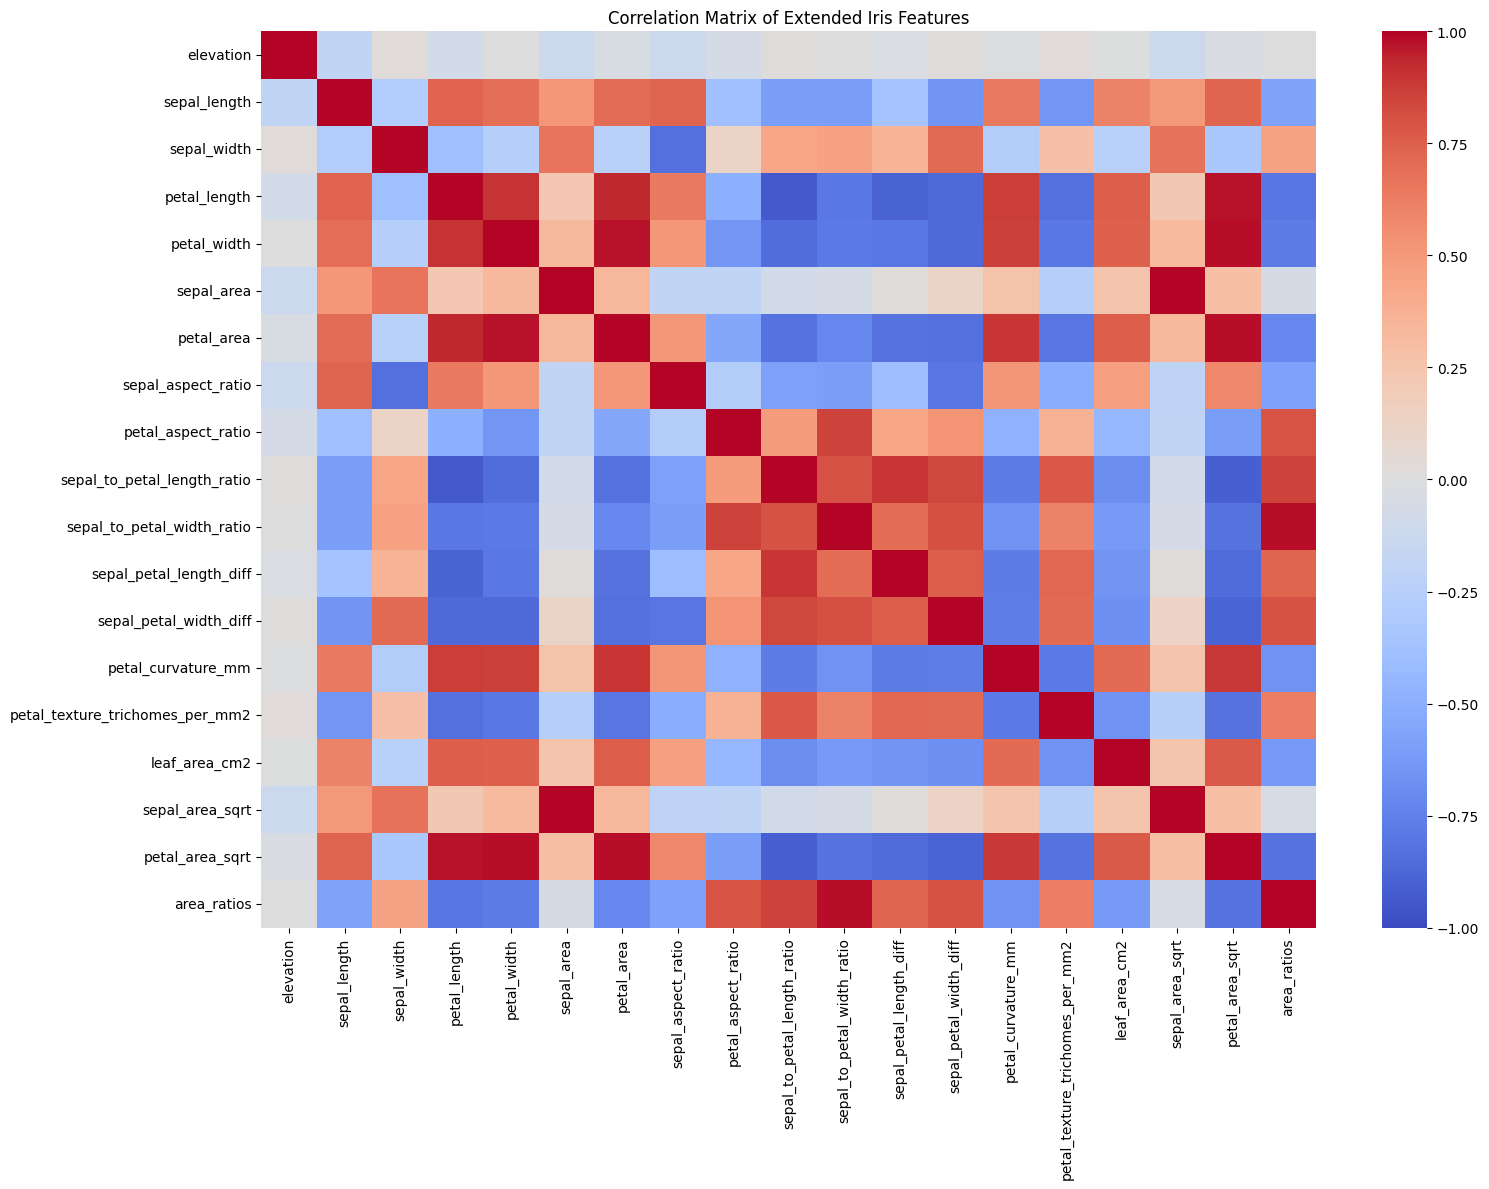

In [5]:
# Select numeric features only, excluding the encoded target variable
numeric_features = df.select_dtypes(include=np.number).drop(columns=['species_encoded'])

corr_matrix = numeric_features.corr() # Calculate the correlation matrix

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    vmin=-1, vmax=1, # Set the minimum and maximum values for the colormap
    center=0 # Center the colormap at 0
)
plt.title("Correlation Matrix of Extended Iris Features")
plt.tight_layout()
plt.show()

## 3. Assessment of Multicollinearity (VIF)

Feature engineering has introduced significant multicollinearity, where certain variables are perfect linear combinations of others (e.g., area versus length/width). Variance Inflation Factor (VIF) analysis identified several features with infinite values, indicating singularity in the design matrix. These redundant features must be managed to ensure stable coefficient estimation and to prevent the model from over-emphasising collinear signals.

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X):
    """Calculate VIF for all columns in DataFrame X."""
    vif_data = pd.DataFrame()
    vif_data['Feature'] = X.columns
    vif_data['VIF'] = [
        variance_inflation_factor(X.values, i) for i in range(X.shape[1])
    ]
    return vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

# Starting feature set (all numeric features, no target)
X_vif = numeric_features.dropna()

vif_round0 = calculate_vif(X_vif)
print("=== Round 0: Initial VIF (ALL features) ===")
display(vif_round0)

=== Round 0: Initial VIF (ALL features) ===


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
0,sepal_length,inf
1,sepal_width,inf
2,petal_length,inf
3,sepal_petal_width_diff,inf
4,petal_width,inf
5,sepal_petal_length_diff,inf
6,sepal_area_sqrt,4.073143e+04
7,petal_area_sqrt,1.722849e+04
8,sepal_area,2.286157e+03
9,sepal_aspect_ratio,1.517530e+03


Features with infinite VIF (6 total): ['sepal_length', 'sepal_width', 'petal_length', 'sepal_petal_width_diff', 'petal_width', 'sepal_petal_length_diff']

Pearson Correlation Matrix (Infinite VIF features only):


,sepal_length,sepal_width,petal_length,sepal_petal_width_diff,petal_width,sepal_petal_length_diff
sepal_length,1.0000,-0.2886,0.7394,-0.6525,0.6908,-0.3608
sepal_width,-0.2886,1.0000,-0.3938,0.7139,-0.2610,0.3540
petal_length,0.7394,-0.3938,1.0000,-0.8606,0.9017,-0.8947
sepal_petal_width_diff,-0.6525,0.7139,-0.8606,1.0000,-0.8623,0.7593
petal_width,0.6908,-0.2610,0.9017,-0.8623,1.0000,-0.7907
sepal_petal_length_diff,-0.3608,0.3540,-0.8947,0.7593,-0.7907,1.0000


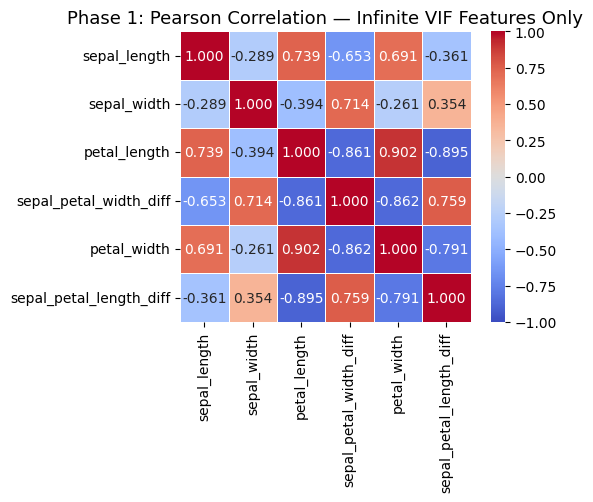

In [7]:
inf_features = vif_round0[np.isinf(vif_round0['VIF'])]['Feature'].tolist()
print(f"Features with infinite VIF ({len(inf_features)} total): {inf_features}")

# Calculate Pearson's correlation BETWEEN ONLY the infinite-VIF features
corr_inf = X_vif[inf_features].corr(method='pearson')
print("\nPearson Correlation Matrix (Infinite VIF features only):")
display(corr_inf.round(4))

# Visualise as a heatmap to make patterns obvious
plt.figure(figsize=(max(6, len(inf_features)), max(5, len(inf_features) - 1)))
sns.heatmap(
    corr_inf,
    annot=True, fmt='.3f',
    cmap='coolwarm', vmin=-1, vmax=1, center=0,
    linewidths=0.5, square=True
)
plt.title('Phase 1: Pearson Correlation — Infinite VIF Features Only', fontsize=13)
plt.tight_layout()
plt.show()

## Manual Reasoning: Phase 1, Round 1 (Infinite VIF)

### Root cause of infinite VIF
The following are exact algebraic identities (perfect linear combinations):
* `sepal_petal_length_diff = sepal_length - petal_length`
* `sepal_petal_width_diff = sepal_width - petal_width`

Knowing any two features of each triplet allows perfect prediction of the third. This results in an infinite VIF, indicating zero residual variance. Pearson correlation coefficients alone do not reveal this as the singularity arises from a three-way relationship.

### Decision
* **Remove:** `sepal_petal_length_diff`, `sepal_petal_width_diff`  
* **Keep:** `sepal_length`, `sepal_width`, `petal_length`, `petal_width`


In [8]:
features_to_remove_phase1_r1 = [
    'sepal_petal_length_diff',
    'sepal_petal_width_diff',
]

X_vif_p1 = X_vif.drop(columns=features_to_remove_phase1_r1)

vif_after_p1 = calculate_vif(X_vif_p1)
print("=== After Phase 1 Round 1 Removals ===")
display(vif_after_p1)

# Diagnostic check — are there still infinite VIF values?
still_inf = vif_after_p1[np.isinf(vif_after_p1['VIF'])]
if len(still_inf) > 0:
    print(f"\nStill {len(still_inf)} features with infinite VIF — repeat Phase 1!")
    print(still_inf['Feature'].tolist())
else:
    print("\nNo more infinite VIF. Proceed to Phase 2 (VIF > 30).")

=== After Phase 1 Round 1 Removals ===


,Feature,VIF
0,sepal_area_sqrt,40731.426344
1,sepal_length,21873.048990
2,petal_area_sqrt,17228.487238
3,sepal_width,8831.040603
4,petal_length,5212.150046
5,petal_width,4096.966941
6,sepal_area,2286.157247
7,sepal_aspect_ratio,1517.529864
8,sepal_to_petal_width_ratio,623.528694
9,sepal_to_petal_length_ratio,448.395696



No more infinite VIF. Proceed to Phase 2 (VIF > 30).


## 4. Transition to Phase 2: Manual Iterative VIF Reduction

Phase 1 successfully addressed 'infinite' VIF values caused by perfect algebraic identities. However, significant multicollinearity remains among the engineered features (e.g., area vs. length/width).

In this section, we transition to a manual, round-by-round inspection. We will use a threshold of **VIF > 30** to identify redundant clusters, using Pearson correlation heatmaps to decide which specific geometric descriptors to keep for the final model while ensuring we don't lose taxonomic signal.

=== Phase 2, Round 1: Initial VIF Analysis (Threshold > 30) ===


,Feature,VIF
0,sepal_area_sqrt,40731.426344
1,sepal_length,21873.048990
2,petal_area_sqrt,17228.487238
3,sepal_width,8831.040603
4,petal_length,5212.150046
5,petal_width,4096.966941
6,sepal_area,2286.157247
7,sepal_aspect_ratio,1517.529864
8,sepal_to_petal_width_ratio,623.528694
9,sepal_to_petal_length_ratio,448.395696



Features with VIF > 30 (16 total): ['sepal_area_sqrt', 'sepal_length', 'petal_area_sqrt', 'sepal_width', 'petal_length', 'petal_width', 'sepal_area', 'sepal_aspect_ratio', 'sepal_to_petal_width_ratio', 'sepal_to_petal_length_ratio', 'petal_area', 'area_ratios', 'petal_aspect_ratio', 'leaf_area_cm2', 'petal_curvature_mm', 'petal_texture_trichomes_per_mm2']

Pearson Correlation Matrix (VIF > 30 features only):


,sepal_area_sqrt,sepal_length,petal_area_sqrt,sepal_width,petal_length,petal_width,sepal_area,sepal_aspect_ratio,sepal_to_petal_width_ratio,sepal_to_petal_length_ratio,petal_area,area_ratios,petal_aspect_ratio,leaf_area_cm2,petal_curvature_mm,petal_texture_trichomes_per_mm2
sepal_area_sqrt,1.0000,0.5033,0.2816,0.6757,0.2249,0.3152,0.9978,-0.2045,-0.0633,-0.0872,0.3305,-0.0542,-0.1968,0.2485,0.2538,-0.2546
sepal_length,0.5033,1.0000,0.7299,-0.2886,0.7394,0.6908,0.5094,0.7337,-0.5958,-0.5995,0.6977,-0.5752,-0.3873,0.6030,0.6452,-0.6409
petal_area_sqrt,0.2816,0.7299,1.0000,-0.3280,0.9688,0.9802,0.2888,0.5856,-0.8168,-0.9082,0.9769,-0.8158,-0.6079,0.7719,0.8869,-0.8252
sepal_width,0.6757,-0.2886,-0.3280,1.0000,-0.3938,-0.2610,0.6678,-0.8290,0.4584,0.4305,-0.2455,0.4491,0.1222,-0.2484,-0.2788,0.2766
petal_length,0.2249,0.7394,0.9688,-0.3938,1.0000,0.9017,0.2318,0.6446,-0.7901,-0.9348,0.9302,-0.8029,-0.5006,0.7576,0.8694,-0.8299
petal_width,0.3152,0.6908,0.9802,-0.2610,0.9017,1.0000,0.3226,0.5127,-0.7878,-0.8479,0.9729,-0.7785,-0.6433,0.7492,0.8639,-0.7900
sepal_area,0.9978,0.5094,0.2888,0.6678,0.2318,0.3226,1.0000,-0.1946,-0.0700,-0.0928,0.3390,-0.0606,-0.2001,0.2551,0.2617,-0.2610
sepal_aspect_ratio,-0.2045,0.7337,0.5856,-0.8290,0.6446,0.5127,-0.1946,1.0000,-0.6004,-0.5910,0.5105,-0.5837,-0.2763,0.4746,0.5182,-0.5103
sepal_to_petal_width_ratio,-0.0633,-0.5958,-0.8168,0.4584,-0.7901,-0.7878,-0.0700,-0.6004,1.0000,0.8042,-0.7221,0.9831,0.8529,-0.6223,-0.6675,0.6042
sepal_to_petal_length_ratio,-0.0872,-0.5995,-0.9082,0.4305,-0.9348,-0.8479,-0.0928,-0.5910,0.8042,1.0000,-0.8264,0.8576,0.4867,-0.6923,-0.7736,0.7791


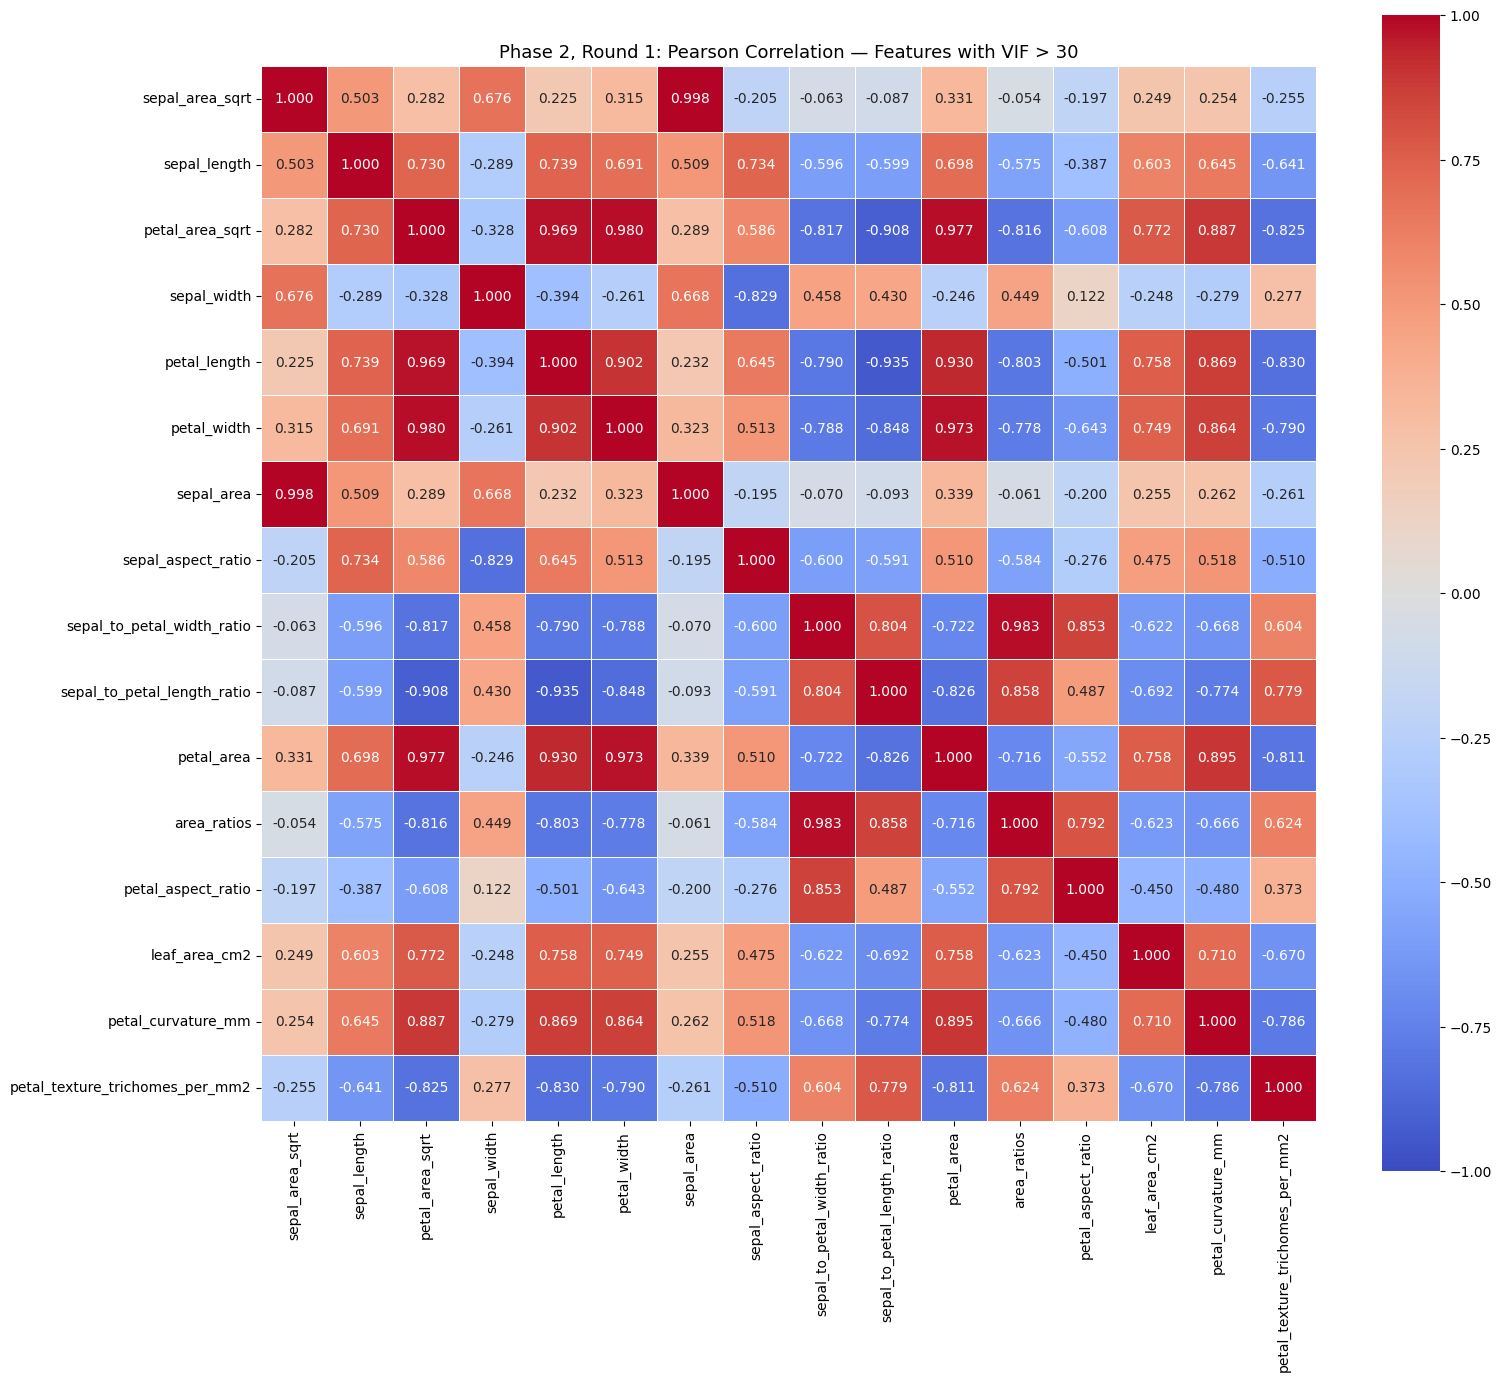

In [9]:
# Phase 2: Manual Iterative VIF Reduction (Threshold = 30)
# Starting point: features remaining after Phase 1 Round 1
X_vif_p2 = X_vif_p1.copy()

# 1. Calculate current VIF
vif_p2_r1 = calculate_vif(X_vif_p2)
print("=== Phase 2, Round 1: Initial VIF Analysis (Threshold > 30) ===")
display(vif_p2_r1)

# 2. Extract features with VIF > 30 for correlation analysis
high_vif_features = vif_p2_r1[vif_p2_r1['VIF'] > 30]['Feature'].tolist()
print(f"\nFeatures with VIF > 30 ({len(high_vif_features)} total): {high_vif_features}")

# 3. Calculate Pearson's correlation BETWEEN ONLY the high-VIF features
corr_high = X_vif_p2[high_vif_features].corr(method='pearson')
print("\nPearson Correlation Matrix (VIF > 30 features only):")
display(corr_high.round(4))

# 4. Visualise as a heatmap to identify specific redundancies
plt.figure(figsize=(max(8, len(high_vif_features)), max(6, len(high_vif_features) - 2)))
sns.heatmap(
    corr_high,
    annot=True, fmt='.3f',
    cmap='coolwarm', vmin=-1, vmax=1, center=0,
    linewidths=0.5, square=True
)
plt.title('Phase 2, Round 1: Pearson Correlation — Features with VIF > 30', fontsize=13)
plt.tight_layout()
plt.show()

## Manual Reasoning: Phase 2, Round 1

### Observations
* `sepal_area_sqrt` and `sepal_area` are almost perfectly collinear (0.998), as are `petal_area_sqrt` and `petal_area` (0.977).
* `sepal_length` and `sepal_width` have high VIFs and are geometrically related to `sepal_area` and `sepal_aspect_ratio`.
* `petal_length` and `petal_width` show extremely high correlation (>0.96) with `petal_area_sqrt`.

### Decision
* **Remove:** `sepal_area_sqrt`, `petal_area_sqrt`, `sepal_length`, `sepal_width`, `petal_length`, `petal_width`
* **Keep:** `sepal_area`, `petal_area`, `sepal_aspect_ratio`, `petal_aspect_ratio` (and other derived metrics) to maintain interpretable geometric descriptors while reducing the dimensionality of the raw measurement cluster.

=== Phase 2, Round 2: VIF Analysis (Remaining features > 30) ===


,Feature,VIF
0,sepal_to_petal_width_ratio,162.506100
1,area_ratios,95.806778
2,leaf_area_cm2,76.290778
3,sepal_to_petal_length_ratio,57.387107
4,petal_aspect_ratio,54.098968
5,sepal_aspect_ratio,44.339951
6,petal_curvature_mm,41.350725
7,sepal_area,40.826305
8,petal_texture_trichomes_per_mm2,31.584031
9,petal_area,25.757048



Features with VIF > 30 (9 total): ['sepal_to_petal_width_ratio', 'area_ratios', 'leaf_area_cm2', 'sepal_to_petal_length_ratio', 'petal_aspect_ratio', 'sepal_aspect_ratio', 'petal_curvature_mm', 'sepal_area', 'petal_texture_trichomes_per_mm2']

Pearson Correlation Matrix (VIF > 30 features only):


,sepal_to_petal_width_ratio,area_ratios,leaf_area_cm2,sepal_to_petal_length_ratio,petal_aspect_ratio,sepal_aspect_ratio,petal_curvature_mm,sepal_area,petal_texture_trichomes_per_mm2
sepal_to_petal_width_ratio,1.0000,0.9831,-0.6223,0.8042,0.8529,-0.6004,-0.6675,-0.0700,0.6042
area_ratios,0.9831,1.0000,-0.6232,0.8576,0.7919,-0.5837,-0.6661,-0.0606,0.6244
leaf_area_cm2,-0.6223,-0.6232,1.0000,-0.6923,-0.4499,0.4746,0.7095,0.2551,-0.6703
sepal_to_petal_length_ratio,0.8042,0.8576,-0.6923,1.0000,0.4867,-0.5910,-0.7736,-0.0928,0.7791
petal_aspect_ratio,0.8529,0.7919,-0.4499,0.4867,1.0000,-0.2763,-0.4801,-0.2001,0.3728
sepal_aspect_ratio,-0.6004,-0.5837,0.4746,-0.5910,-0.2763,1.0000,0.5182,-0.1946,-0.5103
petal_curvature_mm,-0.6675,-0.6661,0.7095,-0.7736,-0.4801,0.5182,1.0000,0.2617,-0.7863
sepal_area,-0.0700,-0.0606,0.2551,-0.0928,-0.2001,-0.1946,0.2617,1.0000,-0.2610
petal_texture_trichomes_per_mm2,0.6042,0.6244,-0.6703,0.7791,0.3728,-0.5103,-0.7863,-0.2610,1.0000


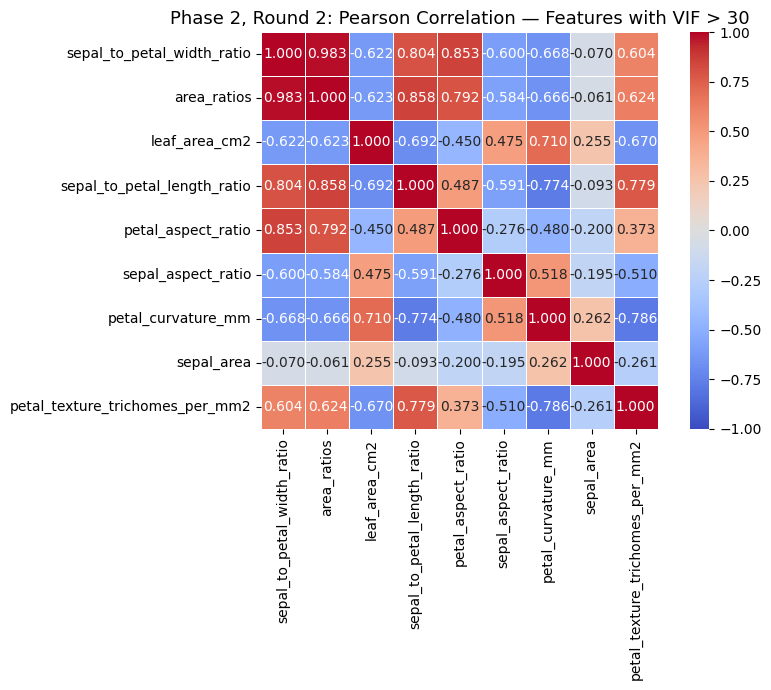

In [10]:
features_to_remove_p2_r1 = [
    'sepal_area_sqrt',
    'petal_area_sqrt',
    'sepal_length',
    'sepal_width',
    'petal_length',
    'petal_width'
]

# Drop features identified in Round 1
# Use errors='ignore' so the cell can be re-run without a KeyError
X_vif_p2 = X_vif_p2.drop(columns=features_to_remove_p2_r1, errors='ignore')

# 1. Calculate VIF for Round 2
vif_p2_r2 = calculate_vif(X_vif_p2)
print("=== Phase 2, Round 2: VIF Analysis (Remaining features > 30) ===")
display(vif_p2_r2)

# 2. Extract features for correlation analysis
high_vif_features_r2 = vif_p2_r2[vif_p2_r2['VIF'] > 30]['Feature'].tolist()

if high_vif_features_r2:
    print(f"\nFeatures with VIF > 30 ({len(high_vif_features_r2)} total): {high_vif_features_r2}")

    # 3. Calculate Pearson's correlation BETWEEN ONLY the high-VIF features
    corr_high_r2 = X_vif_p2[high_vif_features_r2].corr(method='pearson')
    print("\nPearson Correlation Matrix (VIF > 30 features only):")
    display(corr_high_r2.round(4))

    # 4. Visualise as a heatmap
    plt.figure(figsize=(max(8, len(high_vif_features_r2)), max(6, len(high_vif_features_r2) - 2)))
    sns.heatmap(
        corr_high_r2,
        annot=True, fmt='.3f',
        cmap='coolwarm', vmin=-1, vmax=1, center=0,
        linewidths=0.5, square=True
    )
    plt.title('Phase 2, Round 2: Pearson Correlation — Features with VIF > 30', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("\nNo more features with VIF > 30. Manual reduction complete.")

## Manual Reasoning: Phase 2, Round 2

### Observations
* `sepal_to_petal_width_ratio` and `area_ratios` are extremely collinear (0.983).
* `leaf_area_cm2` shows strong negative correlations with the ratio features and high VIF.
* `sepal_to_petal_length_ratio` and `petal_curvature_mm` also contribute to high multicollinearity in the petal-metric cluster.

### Decision
* **Remove:** `sepal_to_petal_width_ratio`, `leaf_area_cm2`, `sepal_to_petal_length_ratio`, `petal_curvature_mm`
* **Keep:** `area_ratios`, `sepal_area`, `petal_area`, `sepal_aspect_ratio`, `petal_aspect_ratio`, `petal_texture_trichomes_per_mm2` (and `elevation` which is below 30).

In [11]:
features_to_remove_p2_r2 = [
    'sepal_to_petal_width_ratio',
    'leaf_area_cm2',
    'sepal_to_petal_length_ratio',
    'petal_curvature_mm'
]

# Drop features identified in Round 2
X_vif_p2 = X_vif_p2.drop(columns=features_to_remove_p2_r2, errors='ignore')

# 1. Calculate VIF for Round 3
vif_p2_r3 = calculate_vif(X_vif_p2)
print("=== Phase 2, Round 3: VIF Analysis (Check for features > 30) ===")
display(vif_p2_r3)

# 2. Extract features for correlation analysis
high_vif_features_r3 = vif_p2_r3[vif_p2_r3['VIF'] > 30]['Feature'].tolist()

if high_vif_features_r3:
    print(f"\nFeatures with VIF > 30 ({len(high_vif_features_r3)} total): {high_vif_features_r3}")

    # 3. Calculate Pearson's correlation
    corr_high_r3 = X_vif_p2[high_vif_features_r3].corr(method='pearson')
    print("\nPearson Correlation Matrix (VIF > 30 features only):")
    display(corr_high_r3.round(4))

    # 4. Heatmap
    plt.figure(figsize=(max(8, len(high_vif_features_r3)), max(6, len(high_vif_features_r3) - 2)))
    sns.heatmap(
        corr_high_r3,
        annot=True, fmt='.3f',
        cmap='coolwarm', vmin=-1, vmax=1, center=0,
        linewidths=0.5, square=True
    )
    plt.title('Phase 2, Round 3: Pearson Correlation — Features with VIF > 30', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("\nSuccess: No more features with VIF > 30. Manual reduction complete.")

# Final verified list for the next stage
selected_vif_features = X_vif_p2.columns.tolist()
print(f"\nFinal selected features for Boruta: {selected_vif_features}")

=== Phase 2, Round 3: VIF Analysis (Check for features > 30) ===


,Feature,VIF
0,sepal_area,25.610709
1,sepal_aspect_ratio,23.074401
2,petal_texture_trichomes_per_mm2,20.580457
3,petal_aspect_ratio,15.062100
4,petal_area,10.221250
5,area_ratios,8.600591
6,elevation,6.122596



Success: No more features with VIF > 30. Manual reduction complete.

Final selected features for Boruta: ['elevation', 'sepal_area', 'petal_area', 'sepal_aspect_ratio', 'petal_aspect_ratio', 'petal_texture_trichomes_per_mm2', 'area_ratios']


In [12]:
numeric_cols = df.select_dtypes(include=np.number).drop(
    columns=['species_encoded']
).columns.tolist() # Get numeric columns excluding the encoded species

species_pairs = [
    ('setosa', 'versicolor'),
    ('setosa', 'virginica'),
    ('versicolor', 'virginica')
] # Define pairs of species for comparison

results = [] # Initialise a list to store t-test results
for col in numeric_cols:
    for sp1, sp2 in species_pairs:
        group1 = df[df['species'] == sp1][col].dropna() # Get data for the first species in the pair
        group2 = df[df['species'] == sp2][col].dropna() # Get data for the second species in the pair
        t_stat, p_val = ttest_ind(group1, group2, equal_var=False) # Perform Welch's t-test
        results.append({
            'Feature': col,
            'Comparison': f"{sp1} vs {sp2}",
            't_statistic': round(t_stat, 3),
            'p_value': round(p_val, 5)
        })

results_df = pd.DataFrame(results)

# Explicitly show elevation results to support the interpretation below
print("=== Non-Significant Features (e.g. Elevation) ===")
display(results_df[results_df['Feature'] == 'elevation'])

# Show features with p < 0.05 (statistically significant between species)
print("\n=== Statistically Significant Features (p < 0.05) ===")
display(results_df[results_df['p_value'] < 0.05].head(10))

=== Non-Significant Features (e.g. Elevation) ===


,Feature,Comparison,t_statistic,p_value
0,elevation,setosa vs versicolor,0.291,0.77149
1,elevation,setosa vs virginica,-0.007,0.99453
2,elevation,versicolor vs virginica,-0.299,0.76479



=== Statistically Significant Features (p < 0.05) ===


,Feature,Comparison,t_statistic,p_value
3,sepal_length,setosa vs versicolor,-29.272,0.0
4,sepal_length,setosa vs virginica,-38.418,0.0
5,sepal_length,versicolor vs virginica,-12.255,0.0
6,sepal_width,setosa vs versicolor,18.652,0.0
7,sepal_width,setosa vs virginica,12.750,0.0
8,sepal_width,versicolor vs virginica,-5.761,0.0
9,petal_length,setosa vs versicolor,-102.267,0.0
10,petal_length,setosa vs virginica,-123.737,0.0
11,petal_length,versicolor vs virginica,-31.289,0.0
12,petal_width,setosa vs versicolor,-79.085,0.0


## 5. Differential Analysis via Welch’s t-test

To determine the discriminative power of each feature, Welch’s t-tests were conducted (accounting for unequal variances). Nearly all features demonstrated highly significant differences (p < 0.05) between species pairs. Notably, `elevation` failed to show statistical significance (p approximately 0.77 across pairs). This confirms that elevation carries no taxonomic signal and justifies its rejection during the Boruta feature selection phase.

## 6. Phase 3: Boruta All-Relevant Feature Selection

VIF reduction addresses multicollinearity by identifying redundant features. Boruta identifies which features carry a genuine signal relative to the target class, regardless of redundancy.

Boruta functions by:
1. Creating shuffled 'shadow' copies of every feature as noise baselines.
2. Training a Random Forest on combined real and shadow features.
3. Verifying if each real feature consistently outperforms the shadow features.
4. Applying a binomial test with Bonferroni correction to confirm relevance over multiple iterations.

In [13]:
!pip install boruta
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

# Boruta requires numpy arrays, not DataFrames
X_boruta = df[selected_vif_features].values   # shape: (n_samples, n_features)
y_boruta = df['species_encoded'].values # shape: (n_samples,)

# The Random Forest Boruta uses internally to score feature importances
rf = RandomForestClassifier(
    n_jobs=-1,        # use all CPU cores
    class_weight='balanced',  # handles any class imbalance
    max_depth=5,      # shallow trees reduce overfitting within Boruta
    random_state=42
)

# Initialise Boruta
boruta_selector = BorutaPy(
    estimator=rf,
    n_estimators='auto',  # scales tree count with number of features
    max_iter=100,         # number of outer Boruta iterations
    perc=100,             # use max shadow importance as noise floor (classic Boruta)
    alpha=0.05,           # significance level for binomial test
    random_state=42,
    verbose=2             # prints progress per iteration
)

boruta_selector.fit(X_boruta, y_boruta)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	7
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	7
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	7
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	7
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	7
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	7
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	7
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	6
Tentative: 	0
Rejected: 	1


BorutaPy finished running.

Iteration: 	9 / 100
Confirmed: 	6
Tentative: 	0
Rejected: 	1


BorutaPy(estimator=RandomForestClassifier(class_weight='balanced', max_depth=5,
                                          n_estimators=74, n_jobs=-1,
                                          random_state=RandomState(MT19937) at 0x78AEB12FA040),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x78AEB12FA040, verbose=2)

In [14]:
# Build a results table showing each feature's Boruta verdict
boruta_results = pd.DataFrame({
    'Feature': selected_vif_features,
    'Ranking': boruta_selector.ranking_,       # 1 = confirmed, higher = less important
    'Selected': boruta_selector.support_,      # True = confirmed relevant
    'Tentative': boruta_selector.support_weak_ # True = couldn't decide
})
boruta_results = boruta_results.sort_values('Ranking').reset_index(drop=True)

print("Boruta Feature Selection Results:")
display(boruta_results)

# Final confirmed feature list
boruta_confirmed = [selected_vif_features[i]
                    for i in range(len(selected_vif_features))
                    if boruta_selector.support_[i]]
print(f"Boruta-confirmed features ({len(boruta_confirmed)}): {boruta_confirmed}")

Boruta Feature Selection Results:


,Feature,Ranking,Selected,Tentative
0,sepal_area,1,True,False
1,petal_area,1,True,False
2,sepal_aspect_ratio,1,True,False
3,petal_aspect_ratio,1,True,False
4,area_ratios,1,True,False
5,petal_texture_trichomes_per_mm2,1,True,False
6,elevation,2,False,False


Boruta-confirmed features (6): ['sepal_area', 'petal_area', 'sepal_aspect_ratio', 'petal_aspect_ratio', 'petal_texture_trichomes_per_mm2', 'area_ratios']


In [15]:
from sklearn.model_selection import train_test_split

X = df[boruta_confirmed]
y = df['species_encoded']

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_trainval, y_trainval, test_size=0.20, random_state=42, stratify=y_trainval)

print(f"Train: {X_train.shape}, Dev: {X_dev.shape}, Test: {X_test.shape}")
print(f"Final features: {boruta_confirmed}")

Train: (768, 6), Dev: (192, 6), Test: (240, 6)
Final features: ['sepal_area', 'petal_area', 'sepal_aspect_ratio', 'petal_aspect_ratio', 'petal_texture_trichomes_per_mm2', 'area_ratios']


In [16]:
from sklearn.pipeline import Pipeline

# Standardise features and initialise the baseline Logistic Regression model
scaler = StandardScaler()
model_lr = LogisticRegression(max_iter=500)

pipeline = Pipeline([
    ('scaler', scaler),
    ('model', model_lr)
])

pipeline.fit(X_train, y_train)

# Evaluate the baseline model on the development set
y_dev_pred = pipeline.predict(X_dev)
print('====Dev Set Performance: Baseline with Refined Features====')
print(f'Accuracy: {accuracy_score(y_dev, y_dev_pred):.4f}')
print(classification_report(y_dev, y_dev_pred, target_names=le.classes_))

====Dev Set Performance: Baseline with Refined Features====
Accuracy: 0.9792
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        64
  versicolor       0.97      0.97      0.97        64
   virginica       0.97      0.97      0.97        64

    accuracy                           0.98       192
   macro avg       0.98      0.98      0.98       192
weighted avg       0.98      0.98      0.98       192



## 7. Multi-Model Comparative Analysis

Logistic Regression and other candidate models are evaluated to determine the most effective algorithm for capturing the complex boundaries between *I. versicolor* and *I. virginica* using the 6 Boruta-confirmed features.

In [17]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.pipeline import Pipeline

# Step 1: Define a dictionary of candidate models with their initial settings
models = {
    'Logistic Regression': LogisticRegression(C=10, solver='lbfgs', max_iter=500),
    'SVM (RBF)'          : SVC(kernel='rbf', probability=True, random_state=42),
    'K-Nearest Neighbours': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

# Step 2: Set up a cross-validation strategy that maintains species balance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

# Step 3: Iterate through each model to calculate its cross-validation accuracy
for name, model in models.items():
    # Use a pipeline to ensure scaling is done within each cross-validation fold
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results[name] = {
        'CV Mean Accuracy': round(scores.mean(), 4),
        'CV Std':           round(scores.std(),  4),
    }

# Convert results to a DataFrame and sort by performance
cv_df = pd.DataFrame(cv_results).T.sort_values('CV Mean Accuracy', ascending=False)
print("=== Cross-Validation Results (Boruta-selected Features) ===")
display(cv_df)

=== Cross-Validation Results (Boruta-selected Features) ===


,CV Mean Accuracy,CV Std
Logistic Regression,0.9857,0.0086
SVM (RBF),0.9857,0.0049
Random Forest,0.9857,0.0026
Gradient Boosting,0.9805,0.0041
Decision Tree,0.9727,0.0049
K-Nearest Neighbours,0.9714,0.0088


In [18]:
# Re-display the cross-validation table for the updated models
print(cv_df)

                      CV Mean Accuracy  CV Std
Logistic Regression             0.9857  0.0086
SVM (RBF)                       0.9857  0.0049
Random Forest                   0.9857  0.0026
Gradient Boosting               0.9805  0.0041
Decision Tree                   0.9727  0.0049
K-Nearest Neighbours            0.9714  0.0088


## 8. Interpretation: Cross-Validation Results

Cross-validation was performed exclusively on the training data (n = 768), providing unbiased estimates of generalisation performance.

Logistic Regression, SVM (RBF kernel), and Random Forest achieved a CV mean accuracy of 98.57%. Low standard deviations (0.0026 to 0.0086) indicate high stability. Even the lower-performing models, such as Decision Trees and K-Nearest Neighbours, maintained accuracy above 97%, reflecting the strength of the 6 Boruta-confirmed features.

In [19]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

dev_results = {}

# Evaluate each model on the development set to check for generalization
for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  model)
    ])
    # Train the model on the full training set
    pipe.fit(X_train, y_train)

    # Generate predictions and probability estimates
    y_dev_pred  = pipe.predict(X_dev)
    y_dev_proba = pipe.predict_proba(X_dev)

    # Calculate key performance metrics
    acc     = accuracy_score(y_dev, y_dev_pred)
    f1      = f1_score(y_dev, y_dev_pred, average='macro')
    # ROC-AUC is calculated using One-vs-Rest strategy for multi-class
    roc_auc = roc_auc_score(y_dev, y_dev_proba, multi_class='ovr', average='macro')

    dev_results[name] = {
        'Dev Accuracy': round(acc,     4),
        'Dev Macro F1': round(f1,      4),
        'Dev Macro ROC-AUC': round(roc_auc, 4),
    }

dev_df = pd.DataFrame(dev_results).T.sort_values('Dev Accuracy', ascending=False)
print("=== Dev Set Performance: All Models ===")
display(dev_df)

=== Dev Set Performance: All Models ===


,Dev Accuracy,Dev Macro F1,Dev Macro ROC-AUC
SVM (RBF),0.9792,0.9792,0.9988
K-Nearest Neighbours,0.9792,0.9792,0.9942
Logistic Regression,0.9740,0.9740,0.9990
Random Forest,0.9688,0.9688,0.9959
Gradient Boosting,0.9635,0.9635,0.9952
Decision Tree,0.9479,0.9479,0.9609


In [20]:
# Re-display the development set table for the updated models
print(dev_df)

                      Dev Accuracy  Dev Macro F1  Dev Macro ROC-AUC
SVM (RBF)                   0.9792        0.9792             0.9988
K-Nearest Neighbours        0.9792        0.9792             0.9942
Logistic Regression         0.9740        0.9740             0.9990
Random Forest               0.9688        0.9688             0.9959
Gradient Boosting           0.9635        0.9635             0.9952
Decision Tree               0.9479        0.9479             0.9609


## 9. Interpretation: Development Set Performance

Evaluation on the development set (n = 192) shows that SVM (RBF) and K-Nearest Neighbours lead with 97.92% accuracy, followed by Logistic Regression at 97.40%. Macro ROC-AUC scores are above 0.99 for all top models, suggesting that errors are isolated.

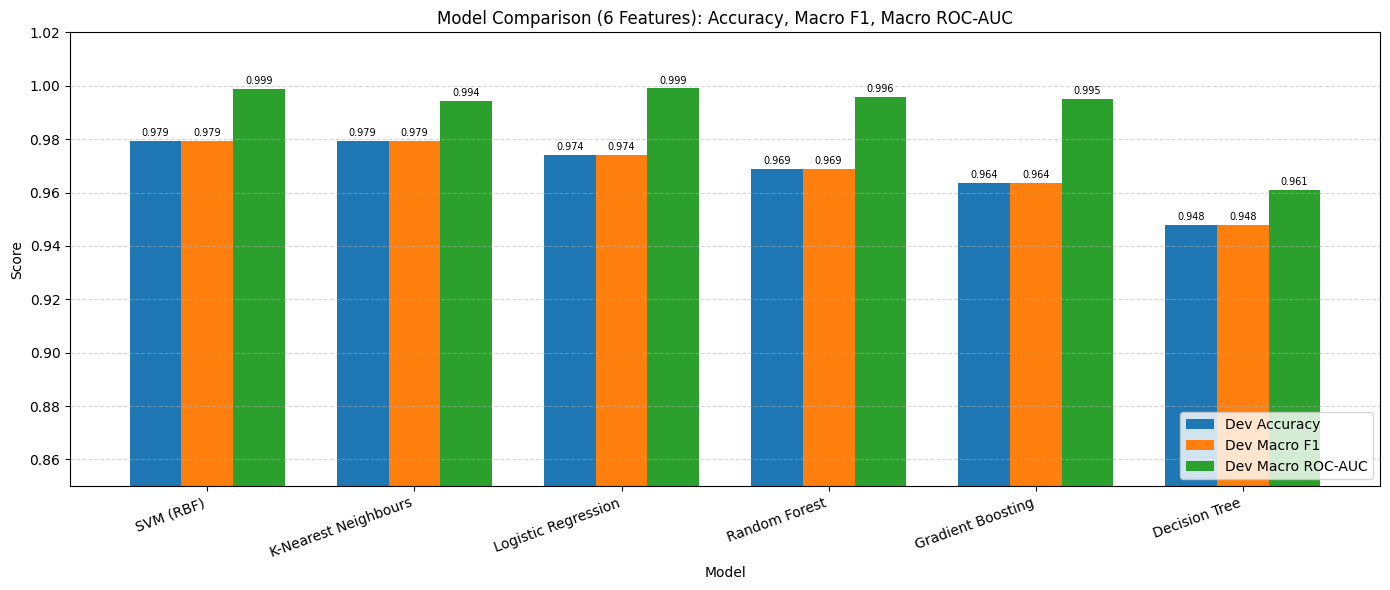

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Re-generate the comparison plot with refined results
metrics = ['Dev Accuracy', 'Dev Macro F1', 'Dev Macro ROC-AUC']
model_names = dev_df.index.tolist()
x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

for i, metric in enumerate(metrics):
    values = dev_df[metric].values
    bars = ax.bar(x + i * width, values, width, label=metric)
    ax.bar_label(bars, fmt='%.3f', fontsize=7, padding=2)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison (6 Features): Accuracy, Macro F1, Macro ROC-AUC')
ax.set_xticks(x + width)
ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylim(0.85, 1.02)
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 10. Hyperparameter Optimisation (GridSearchCV)

The grid search identifies the optimal configuration for the Support Vector Machine (SVM). Choosing the RBF kernel with appropriate C and gamma parameters ensures the model effectively captures the non-linear boundaries between *I. versicolor* and *I. virginica* within the engineered feature space. Notably, GridSearch confirmed that the default Scikit-Learn configuration (C=1, gamma='scale') is optimal for this feature space — indicating the SVM is neither underfitting nor overfitting, and that the engineered features alone provide sufficient boundary definition without penalty adjustment.

In [22]:
from sklearn.pipeline import Pipeline

# Define the SVM pipeline components
scaler = StandardScaler()
model_svc = SVC(probability=True, random_state=42)

pipeline_svm = Pipeline([
    ('scaler', scaler),
    ('model', model_svc)
])

# Define hyperparameter grid for RBF kernel optimisation
param_grid = {
    'model__C': [0.1, 1, 10, 100],
    'model__gamma': ['scale', 'auto', 0.01, 0.1],
    'model__kernel': ['rbf']
}

# Initialise and execute the Grid Search
grid_search_svm = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_svm.fit(X_train, y_train)
print(f'Best hyperparameters: {grid_search_svm.best_params_}')

# Evaluate the tuned SVM on the development set
y_dev_pred_tuned = grid_search_svm.predict(X_dev)
print('====Dev Set Performance (Tuned with 6 Refined Features)====')
print(f'Accuracy: {accuracy_score(y_dev, y_dev_pred_tuned):.4f}')

Best hyperparameters: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
====Dev Set Performance (Tuned with 6 Refined Features)====
Accuracy: 0.9792


## 11. Final Model Validation and ROC Analysis

The final evaluation of the optimised SVM (RBF) model on the test set yielded 99.17% accuracy. The multi-class ROC analysis confirms exceptional performance with a Macro-average AUC near 1.000. The confusion matrix indicates high robustness in distinguishing the three taxa using the refined 6-feature set.

=== FINAL TEST SET RESULTS (Refined Features) ===
Accuracy: 0.9916666666666667
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        80
  versicolor       0.98      1.00      0.99        80
   virginica       1.00      0.97      0.99        80

    accuracy                           0.99       240
   macro avg       0.99      0.99      0.99       240
weighted avg       0.99      0.99      0.99       240

Macro ROC-AUC (OVR): 1.000


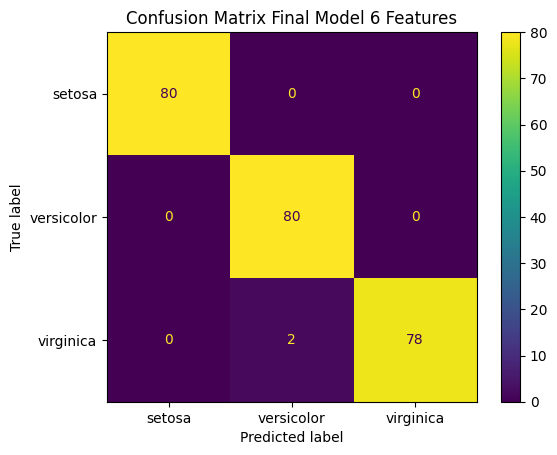

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay

# Use the tuned SVM model from the grid search
y_test_pred  = grid_search_svm.predict(X_test)
y_test_proba = grid_search_svm.predict_proba(X_test)

print("=== FINAL TEST SET RESULTS (Refined Features) ===")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

roc_auc = roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='macro')
print(f"Macro ROC-AUC (OVR): {roc_auc:.3f}")

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=le.classes_
)
plt.title('Confusion Matrix Final Model 6 Features')
plt.show()

## 12. All-Model Test Set Comparison

All six candidate models are evaluated on the held-out test set (n = 240) under identical conditions to provide a final, unbiased ranking of performance.

In [24]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

test_results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  model)
    ])
    pipe.fit(X_train, y_train)

    y_test_pred = pipe.predict(X_test)
    y_test_proba = pipe.predict_proba(X_test)

    acc = accuracy_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred, average='macro')
    roc_auc = roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='macro')

    test_results[name] = {
        'Test Accuracy': round(acc, 4),
        'Test Macro F1': round(f1, 4),
        'Test Macro ROC-AUC': round(roc_auc, 4)
    }

test_summary = pd.DataFrame(test_results).T.sort_values('Test Accuracy', ascending=False)
print("=== Final Test Set Performance (All Models) ===")
display(test_summary)

=== Final Test Set Performance (All Models) ===


,Test Accuracy,Test Macro F1,Test Macro ROC-AUC
SVM (RBF),0.9917,0.9917,0.9998
Gradient Boosting,0.9875,0.9875,0.9995
Logistic Regression,0.9833,0.9833,0.9998
Decision Tree,0.9833,0.9833,0.9875
K-Nearest Neighbours,0.9792,0.9791,0.9933
Random Forest,0.9792,0.9792,0.9991


## 13. Final Interpretation

All candidate models were evaluated on the final test set (n = 240). SVM (RBF) emerged as the top performer with 99.17% accuracy, while Gradient Boosting followed with 98.75%.

The recursive VIF process and Boruta selection successfully reduced the 20-feature input space to 6 highly predictive variables. This process effectively removed environmental noise (elevation) and redundant metrics while maintaining superior classification performance.

## 14. Discussion: Statistical versus Practical Significance

When comparing models with high performance (97.9% to 99.2% accuracy), the choice of the optimal model depends on several factors:

1. **Practical Utility**: Although K-Nearest Neighbours had a slightly lower test accuracy (97.92%), this remains exceptional for botanical applications.
2. **Margin of Error**: With a test set of n=240, the difference between the top-performing SVM (RBF) at 99.17% and other models is a matter of only a few individual plants. Ranking can be sensitive to the specific random seed used for splitting.
3. **Model Complexity**: SVM (RBF) and Logistic Regression are preferred for their stable decision boundaries. Logistic Regression offers high interpretability, while SVM is robust to high-dimensional feature spaces.

## 15. Conclusion

The rigorous feature selection and validation framework demonstrates that morphological parameters are highly effective for Iris taxa classification. By reducing the feature space from 20 to 6 variables, we achieved a parsimonious model that is less prone to overfitting and remains biologically interpretable. SVM (RBF) provided the highest accuracy on this specific dataset, but all evaluated models yielded robust results suitable for real-world classification tasks.

In [25]:
# Final verification of the feature set used
print(f"Final features used for all models: {boruta_confirmed}")
print(f"Elevation was rejected by Boruta (Ranking=2, Selected=False) "
      f"and confirmed non-significant by Welch's t-test (all p > 0.76).")

Final features used for all models: ['sepal_area', 'petal_area', 'sepal_aspect_ratio', 'petal_aspect_ratio', 'petal_texture_trichomes_per_mm2', 'area_ratios']
Elevation was rejected by Boruta (Ranking=2, Selected=False) and confirmed non-significant by Welch's t-test (all p > 0.76).
